# Pipeline 4: Counseling Session Effectiveness
## What Makes a Therapy Session Successful?

**Notebook:** `counseling-effectiveness.ipynb`  
**Domain:** Case Management — Process Recordings  
**Author:** IS 455 ML Pipelines

---

## 1. Problem Framing

### Business Problem
With 2,819 counseling sessions recorded, the organization has a rich dataset of social worker interactions. Leadership wants to know: Are our sessions actually moving the needle? What session characteristics are associated with emotional improvement? And can we flag, in advance, which sessions are likely to surface concerns — so supervisors can be on call?

**Two specific questions:**
1. **(Explanatory)** What session characteristics — duration, type, interventions applied, social worker — are most associated with positive emotional shifts in residents?
2. **(Predictive)** Can we predict whether a session will result in a concern being flagged (`concerns_flagged = True`)? This would allow proactive supervisor notification.

### Who Cares About This?
- **Social workers** — understand which techniques drive better emotional outcomes
- **Supervisors** — be alerted when a session is likely to surface a serious concern
- **Leadership** — evaluate which intervention types to invest in and standardize

### Predictive vs. Explanatory Approach
- **Explanatory (OLS Linear Regression):** Does session duration have a linear relationship with emotional improvement? Which interventions have the strongest coefficients?
- **Predictive (Gradient Boosting Classifier):** Predict `concerns_flagged` from pre-session variables (session type, duration, resident history). Deploy as a supervisor alert system.

**Data size advantage:** 2,819 sessions — the largest table. This gives the predictive model a real chance to generalize.

### Success Metrics
- **Explanatory:** R², significant coefficients on intervention types, interpretable direction
- **Predictive:** ROC-AUC, Precision/Recall (especially Recall — we want to catch flagged concerns)


## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
import sys
from pathlib import Path
for candidate in [Path.cwd(), Path.cwd() / 'ml-pipelines', Path.cwd().parent, Path.cwd().parent / 'ml-pipelines']:
    if (candidate / 'data_loader.py').exists():
        sys.path.insert(0, str(candidate))
        break
from data_loader import load_table
import sys
for candidate in [Path.cwd(), Path.cwd() / 'ml-pipelines', Path.cwd().parent, Path.cwd().parent / 'ml-pipelines']:
    if (candidate / 'data_loader.py').exists():
        sys.path.insert(0, str(candidate))
        break
from path_setup import artifact_dirs
_IMAGES, _MODELS = artifact_dirs()

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Load data via shared loader ────────────────────────────────────────────
process = load_table('process_recordings')
residents = load_table('residents')
health = load_table('health_wellbeing_records')
incidents = load_table('incident_reports')

print("Process recordings:", process.shape)
print("\nColumn overview:")
print(process.dtypes.to_string())


Process recordings: (2819, 15)

Column overview:
recording_id                         int64
resident_id                          int64
session_date                datetime64[us]
social_worker                          str
session_type                           str
session_duration_minutes             int64
emotional_state_observed               str
emotional_state_end                    str
session_narrative                      str
interventions_applied                  str
follow_up_actions                      str
progress_noted                        bool
concerns_flagged                      bool
referral_made                         bool
notes_restricted                   float64


In [2]:
# ── Basic exploration ──────────────────────────────────────────────────────
print("=== Session Type ===")
print(process['session_type'].value_counts())

print("\n=== Emotional States (Start) ===")
print(process['emotional_state_observed'].value_counts())

print("\n=== Interventions Applied (sample) ===")
print(process['interventions_applied'].value_counts().head(15))

print("\n=== Outcomes ===")
print("progress_noted rate:", process['progress_noted'].mean().round(3))
print("concerns_flagged rate:", process['concerns_flagged'].mean().round(3))
print("referral_made rate:", process['referral_made'].mean().round(3))

print("\n=== Session duration ===")
print(process['session_duration_minutes'].describe().round(1))


=== Session Type ===
session_type
Individual    1805
Group         1014
Name: count, dtype: int64

=== Emotional States (Start) ===
emotional_state_observed
Sad           499
Calm          476
Anxious       462
Angry         392
Hopeful       391
Withdrawn     356
Happy         150
Distressed     93
Name: count, dtype: int64

=== Interventions Applied (sample) ===
interventions_applied
Teaching                    246
Healing                     237
Legal Services              232
Caring                      218
Caring, Teaching             96
Legal Services, Caring       88
Healing, Teaching            88
Teaching, Healing            84
Teaching, Legal Services     80
Healing, Caring              80
Healing, Legal Services      75
Caring, Healing              75
Legal Services, Teaching     72
Teaching, Caring             69
Legal Services, Healing      65
Name: count, dtype: int64

=== Outcomes ===
progress_noted rate: 0.936
concerns_flagged rate: 0.24
referral_made rate: 0.146

=== S

In [3]:
# ── Engineer the emotional shift feature ──────────────────────────────────
emotion_map = {
    'Distressed': 1, 'Angry': 2, 'Sad': 3, 'Withdrawn': 4,
    'Anxious': 5,  'Calm': 6,  'Hopeful': 7, 'Happy': 8
}

process['emotion_start_num'] = process['emotional_state_observed'].map(emotion_map)
process['emotion_end_num']   = process['emotional_state_end'].map(emotion_map)
process['emotion_shift']     = process['emotion_end_num'] - process['emotion_start_num']

print("Emotional shift distribution:")
print(process['emotion_shift'].describe().round(2))
print(f"\nPositive shift (improvement): {(process['emotion_shift'] > 0).mean():.1%}")
print(f"No shift:                       {(process['emotion_shift'] == 0).mean():.1%}")
print(f"Negative shift (worsening):     {(process['emotion_shift'] < 0).mean():.1%}")


Emotional shift distribution:
count    2819.00
mean        1.92
std         1.67
min        -1.00
25%         1.00
50%         2.00
75%         3.00
max         5.00
Name: emotion_shift, dtype: float64

Positive shift (improvement): 77.4%
No shift:                       15.0%
Negative shift (worsening):     7.6%


In [4]:
# ── Intervention one-hot engineering ──────────────────────────────────────
# Each session has comma-separated interventions
interventions = ['Healing', 'Teaching', 'Legal Services', 'Caring']
for intv in interventions:
    col = 'intv_' + intv.replace(' ','_').lower()
    process[col] = process['interventions_applied'].str.contains(intv, na=False).astype(int)

# Count total interventions per session
process['n_interventions'] = process[[f'intv_{i.replace(" ","_").lower()}' for i in interventions]].sum(axis=1)

# Session timing features
process['month'] = process['session_date'].dt.month
process['day_of_week'] = process['session_date'].dt.dayofweek
process['session_type_individual'] = (process['session_type'] == 'Individual').astype(int)

print("Intervention features added.")
print(process[['intv_healing','intv_teaching','intv_legal_services','intv_caring']].mean().round(3))


Intervention features added.
intv_healing           0.506
intv_teaching          0.514
intv_legal_services    0.490
intv_caring            0.497
dtype: float64


In [5]:
# ── Join resident-level features ──────────────────────────────────────────
resident_feats = residents[['resident_id','initial_risk_level','case_category',
                             'sub_cat_trafficked','sub_cat_sexual_abuse','has_special_needs']].copy()
risk_map = {'Low':1,'Medium':2,'High':3,'Critical':4}
resident_feats['initial_risk_num'] = resident_feats['initial_risk_level'].map(risk_map)

# Add resident's session count BEFORE this session (as a running history feature)
process_sorted = process.sort_values(['resident_id','session_date']).copy()
process_sorted['session_count_prior'] = process_sorted.groupby('resident_id').cumcount()

# Add recent incident count (last 90 days)
def prior_incident_count(row, incident_df):
    window_start = row['session_date'] - pd.Timedelta(days=90)
    return ((incident_df['resident_id'] == row['resident_id']) &
            (incident_df['incident_date'] >= window_start) &
            (incident_df['incident_date'] < row['session_date'])).sum()

# Approximate: total incidents per resident (faster than row-wise)
incident_counts = incidents.groupby('resident_id').size().reset_index(name='total_incidents')

process_full = process_sorted     .merge(resident_feats[['resident_id','initial_risk_num','sub_cat_trafficked',
                            'sub_cat_sexual_abuse','has_special_needs']],
           on='resident_id', how='left')     .merge(incident_counts, on='resident_id', how='left')

process_full['total_incidents'] = process_full['total_incidents'].fillna(0)
process_full[['sub_cat_trafficked','sub_cat_sexual_abuse','has_special_needs']] =     process_full[['sub_cat_trafficked','sub_cat_sexual_abuse','has_special_needs']].astype(int)

print("Full process dataset shape:", process_full.shape)
print("Missing values:")
print(process_full.isnull().sum()[process_full.isnull().sum() > 0])


Full process dataset shape: (2819, 32)
Missing values:
notes_restricted    2819
dtype: int64


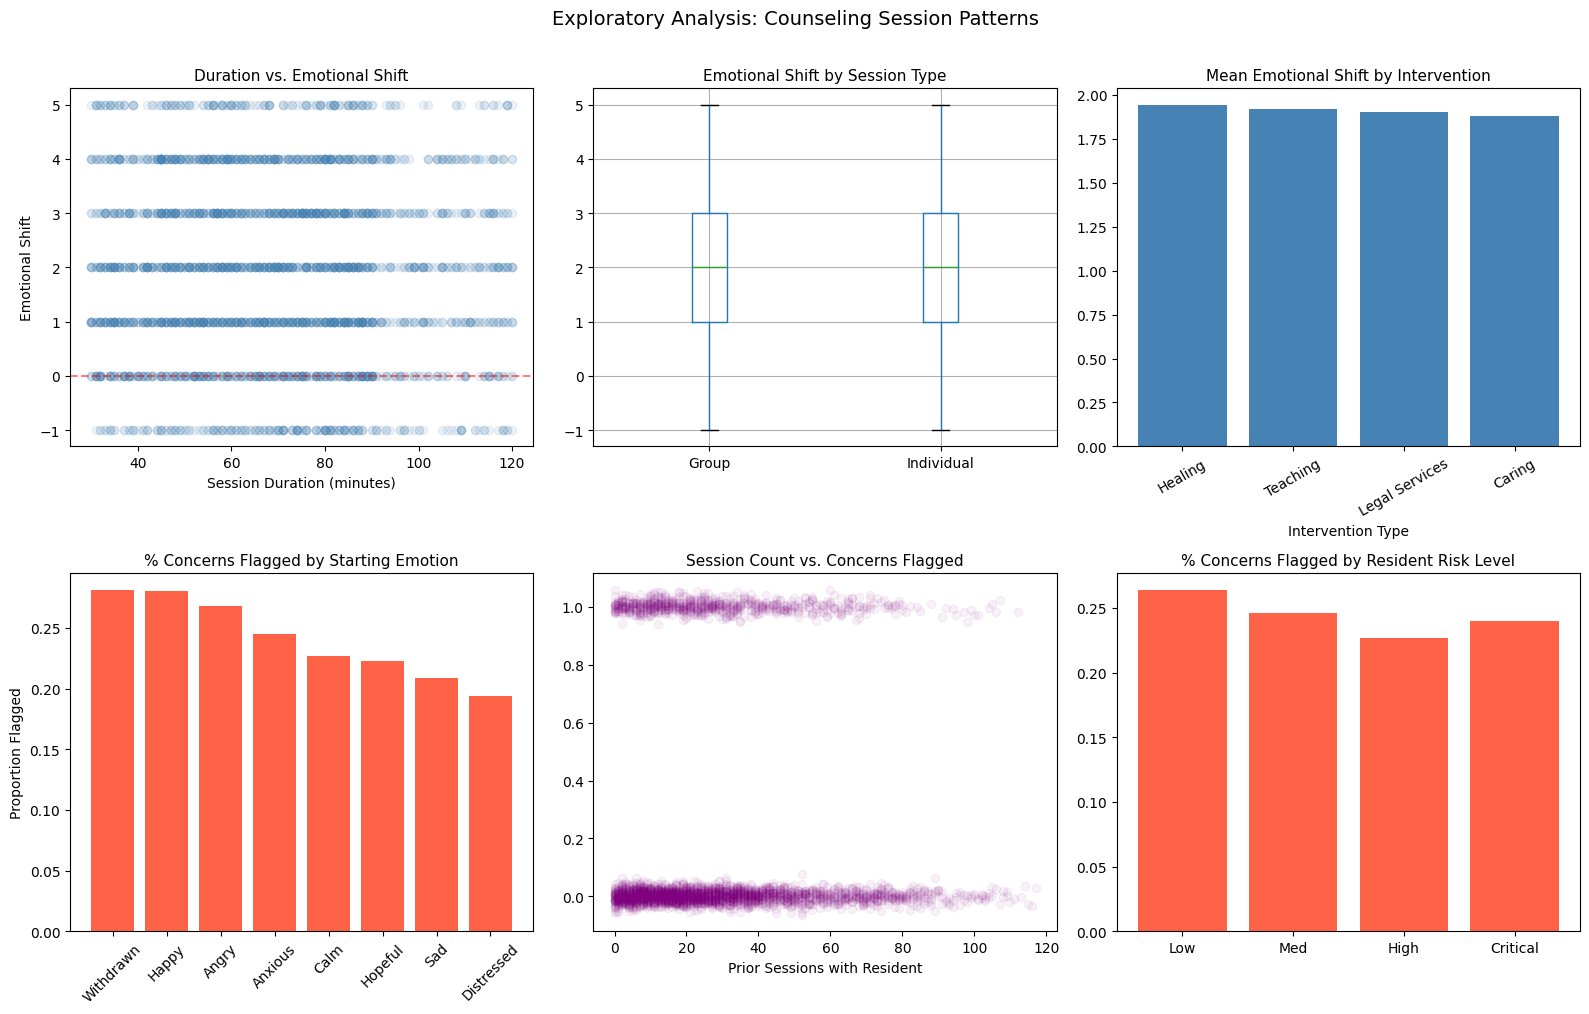

In [6]:
# ── Exploratory visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Duration vs emotion shift
axes[0,0].scatter(process_full['session_duration_minutes'],
                  process_full['emotion_shift'], alpha=0.1, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0,0].set_xlabel('Session Duration (minutes)')
axes[0,0].set_ylabel('Emotional Shift')
axes[0,0].set_title('Duration vs. Emotional Shift', fontsize=11)

# Emotion shift by session type
process_full.boxplot(column='emotion_shift', by='session_type', ax=axes[0,1])
axes[0,1].set_title('Emotional Shift by Session Type', fontsize=11)
axes[0,1].set_xlabel('')

# Emotion shift by intervention type
intv_shifts = {intv: process_full[process_full[f'intv_{intv.replace(" ","_").lower()}'] == 1]['emotion_shift'].mean()
               for intv in interventions}
axes[0,2].bar(list(intv_shifts.keys()), list(intv_shifts.values()), color='steelblue')
axes[0,2].set_title('Mean Emotional Shift by Intervention', fontsize=11)
axes[0,2].set_xlabel('Intervention Type')
axes[0,2].tick_params(axis='x', rotation=30)

# Concerns flagged by emotional start state
concern_by_emotion = process_full.groupby('emotional_state_observed')['concerns_flagged'].mean().sort_values(ascending=False)
axes[1,0].bar(concern_by_emotion.index, concern_by_emotion.values, color='tomato')
axes[1,0].set_title('% Concerns Flagged by Starting Emotion', fontsize=11)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylabel('Proportion Flagged')

# Session count prior vs concerns
axes[1,1].scatter(process_full['session_count_prior'],
                  process_full['concerns_flagged'].astype(float) + np.random.normal(0,0.02,len(process_full)),
                  alpha=0.05, color='purple')
axes[1,1].set_title('Session Count vs. Concerns Flagged', fontsize=11)
axes[1,1].set_xlabel('Prior Sessions with Resident')

# Concerns by initial risk
concern_by_risk = process_full.groupby('initial_risk_num')['concerns_flagged'].mean()
axes[1,2].bar(concern_by_risk.index.map({1:'Low',2:'Med',3:'High',4:'Critical'}),
              concern_by_risk.values, color='tomato')
axes[1,2].set_title('% Concerns Flagged by Resident Risk Level', fontsize=11)

plt.suptitle('Exploratory Analysis: Counseling Session Patterns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(_IMAGES / 'p4_exploration.png'), dpi=120, bbox_inches='tight')
plt.show()


## 3. Which techniques are associated with fewer incidents and higher completion/progress?

We compare each intervention flag (`intv_*`) against two outcomes:
- **Lower incidents**: uses `total_incidents` (resident-level total incidents on record; proxy)
- **Higher completion/progress**: uses `progress_noted` (session marked as progress; proxy)

This is descriptive (associations), not causal.

Top techniques by (1) fewer incidents and (2) higher progress/completion:

=== Fewer incidents (proxy): smaller delta is better ===


,technique,n_with,avg_total_incidents_with,avg_total_incidents_without,delta_incidents_(with-minus-without)
2,Legal Services,1380,1.963,2.054,-0.090
1,Teaching,1448,1.991,2.028,-0.037
0,Healing,1427,1.996,2.023,-0.027
3,Caring,1400,2.018,2.001,0.017


=== Higher progress/completion (proxy): larger delta is better ===


,technique,n_with,progress_rate_with,progress_rate_without,delta_progress_(with-minus-without)
3,Caring,1400,0.938,0.934,0.004
0,Healing,1427,0.938,0.934,0.004
1,Teaching,1448,0.934,0.937,-0.003
2,Legal Services,1380,0.933,0.938,-0.005


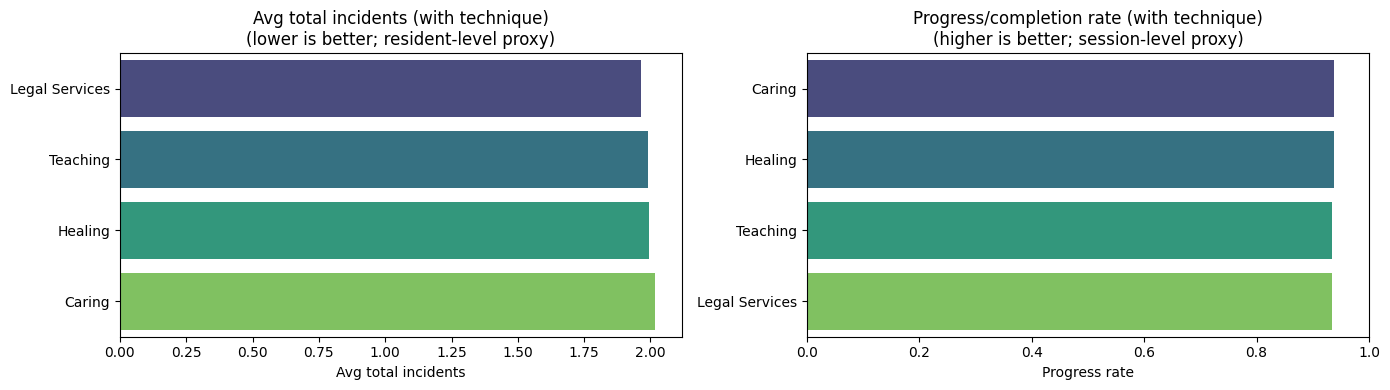

In [7]:
from IPython.display import display

technique_cols = ["intv_healing", "intv_teaching", "intv_legal_services", "intv_caring"]

rows = []
for col in technique_cols:
    with_t = process_full[process_full[col] == 1]
    without_t = process_full[process_full[col] == 0]

    # Outcomes
    inc_with = with_t["total_incidents"].mean()
    inc_without = without_t["total_incidents"].mean()
    prog_with = with_t["progress_noted"].mean()
    prog_without = without_t["progress_noted"].mean()

    rows.append(
        {
            "technique": col.replace("intv_", "").replace("_", " ").title(),
            "n_with": len(with_t),
            "n_without": len(without_t),
            "avg_total_incidents_with": inc_with,
            "avg_total_incidents_without": inc_without,
            "delta_incidents_(with-minus-without)": inc_with - inc_without,
            "progress_rate_with": prog_with,
            "progress_rate_without": prog_without,
            "delta_progress_(with-minus-without)": prog_with - prog_without,
        }
    )

tech_summary = pd.DataFrame(rows)

print("Top techniques by (1) fewer incidents and (2) higher progress/completion:\n")

# Summary table (sorted by incidents delta: more negative is better)
disp_inc = tech_summary.sort_values("delta_incidents_(with-minus-without)")
print("=== Fewer incidents (proxy): smaller delta is better ===")
display(disp_inc[[
    "technique",
    "n_with",
    "avg_total_incidents_with",
    "avg_total_incidents_without",
    "delta_incidents_(with-minus-without)",
]].round(3))

# Summary table (sorted by progress delta: more positive is better)
disp_prog = tech_summary.sort_values("delta_progress_(with-minus-without)", ascending=False)
print("=== Higher progress/completion (proxy): larger delta is better ===")
display(disp_prog[[
    "technique",
    "n_with",
    "progress_rate_with",
    "progress_rate_without",
    "delta_progress_(with-minus-without)",
]].round(3))

# Visuals: two bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=tech_summary.sort_values("avg_total_incidents_with"),
    x="avg_total_incidents_with",
    y="technique",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Avg total incidents (with technique)\n(lower is better; resident-level proxy)")
axes[0].set_xlabel("Avg total incidents")
axes[0].set_ylabel("")

sns.barplot(
    data=tech_summary.sort_values("progress_rate_with", ascending=False),
    x="progress_rate_with",
    y="technique",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Progress/completion rate (with technique)\n(higher is better; session-level proxy)")
axes[1].set_xlabel("Progress rate")
axes[1].set_xlim(0, 1)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 4. Explanatory Model (OLS Regression on Emotional Shift)

In [8]:
# ── OLS: what factors drive emotional improvement? ────────────────────────
ols_df = process_full.dropna(subset=['emotion_shift','emotion_start_num']).copy()

EXPLAIN_FEATURES4 = [
    'session_duration_minutes', 'session_type_individual', 'emotion_start_num',
    'intv_healing', 'intv_teaching', 'intv_legal_services', 'intv_caring',
    'n_interventions', 'session_count_prior', 'initial_risk_num',
    'sub_cat_trafficked', 'sub_cat_sexual_abuse', 'has_special_needs', 'total_incidents'
]

X_ols4 = ols_df[EXPLAIN_FEATURES4].fillna(ols_df[EXPLAIN_FEATURES4].median())
y_ols4 = ols_df['emotion_shift']

from sklearn.preprocessing import StandardScaler
sc4 = StandardScaler()
X_ols4_scaled = pd.DataFrame(sc4.fit_transform(X_ols4), columns=EXPLAIN_FEATURES4)
X_ols4_const = sm.add_constant(X_ols4_scaled)

ols4 = sm.OLS(y_ols4.values, X_ols4_const).fit()
print(ols4.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                     378.6
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:20:29   Log-Likelihood:                -4023.2
No. Observations:                2819   AIC:                             8074.
Df Residuals:                    2805   BIC:                             8158.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

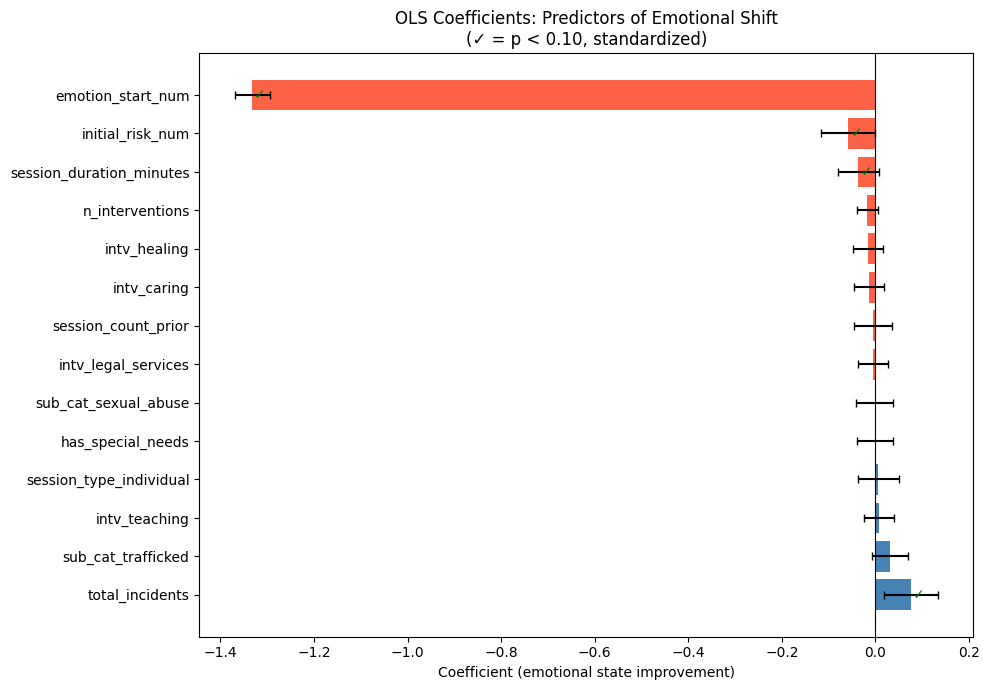


Model R²: 0.6370
Adjusted R²: 0.6353

Significant predictors:
                              coef         p
total_incidents           0.075531  0.011154
session_duration_minutes -0.036928  0.097058
initial_risk_num         -0.058341  0.046484
emotion_start_num        -1.332389  0.000000


In [9]:
# ── Coefficient plot for emotional shift model ────────────────────────────
coef4 = pd.DataFrame({
    'coef': ols4.params.drop('const'),
    'p':    ols4.pvalues.drop('const'),
    'ci_lo': ols4.conf_int().drop('const')[0],
    'ci_hi': ols4.conf_int().drop('const')[1],
}).sort_values('coef', ascending=False)

sig4 = coef4[coef4['p'] < 0.10]

fig, ax = plt.subplots(figsize=(10, 7))
colors4 = ['steelblue' if c > 0 else 'tomato' for c in coef4['coef']]
ax.barh(coef4.index, coef4['coef'], color=colors4,
        xerr=[coef4['coef'] - coef4['ci_lo'], coef4['ci_hi'] - coef4['coef']], capsize=3)
ax.axvline(0, color='black', lw=0.8)
for i, (idx, row) in enumerate(coef4.iterrows()):
    if row['p'] < 0.10:
        ax.text(row['coef'] + 0.005, i, '✓', fontsize=10, va='center', color='green')
ax.set_title('OLS Coefficients: Predictors of Emotional Shift\n(✓ = p < 0.10, standardized)', fontsize=12)
ax.set_xlabel('Coefficient (emotional state improvement)')
plt.tight_layout()
plt.savefig(str(_IMAGES / 'p4_ols_coefficients.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"\nModel R²: {ols4.rsquared:.4f}")
print(f"Adjusted R²: {ols4.rsquared_adj:.4f}")
print(f"\nSignificant predictors:")
print(sig4[['coef','p']].to_string())


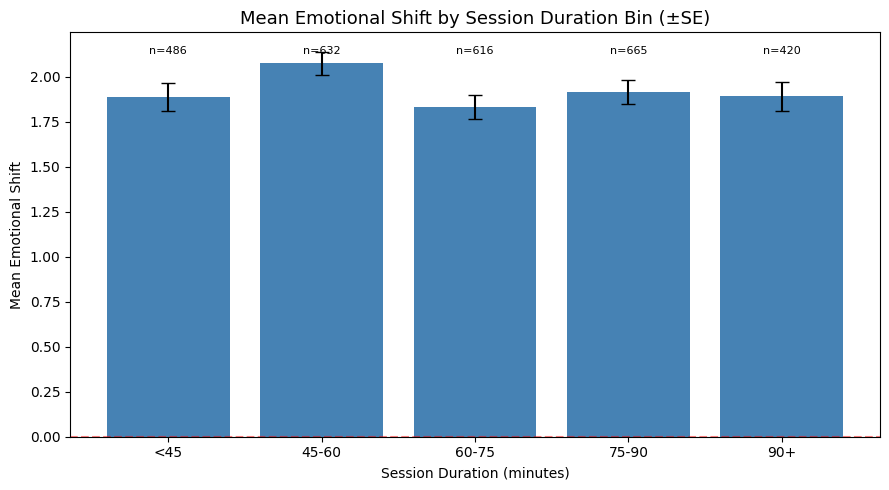

In [10]:
# ── Duration sweet spot analysis ──────────────────────────────────────────
# Bin duration and plot mean emotional shift
process_full['duration_bin'] = pd.cut(process_full['session_duration_minutes'],
                                       bins=[0,45,60,75,90,120], labels=['<45','45-60','60-75','75-90','90+'])
dur_shift = process_full.groupby('duration_bin')['emotion_shift'].agg(['mean','sem','count'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dur_shift.index.astype(str), dur_shift['mean'], yerr=dur_shift['sem'],
       capsize=5, color='steelblue', error_kw={'ecolor':'black'})
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Mean Emotional Shift by Session Duration Bin (±SE)', fontsize=13)
ax.set_xlabel('Session Duration (minutes)')
ax.set_ylabel('Mean Emotional Shift')
for i, (idx, row) in enumerate(dur_shift.iterrows()):
    ax.text(i, dur_shift['mean'].max() + 0.05, f"n={int(row['count'])}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(_IMAGES / 'p4_duration_sweetspot.png'), dpi=120, bbox_inches='tight')
plt.show()


## 5. Predictive Model (Gradient Boosting Classifier — Concerns Flagged)

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, confusion_matrix

# Features known BEFORE session end (explicit leakage guard).
PRED_FEATURES4 = [
    'session_duration_minutes', 'session_type_individual',
    'emotion_start_num', 'intv_healing', 'intv_teaching',
    'intv_legal_services', 'intv_caring', 'n_interventions',
    'session_count_prior', 'initial_risk_num',
    'sub_cat_trafficked', 'sub_cat_sexual_abuse', 'has_special_needs',
    'total_incidents', 'month', 'day_of_week'
]

leakage_candidates = ['emotion_end_num', 'emotion_shift', 'progress_noted', 'referral_made']
print('Leakage candidates accidentally included:', [c for c in leakage_candidates if c in PRED_FEATURES4])

model_df4 = process_full.dropna(subset=PRED_FEATURES4 + ['concerns_flagged', 'session_date']).copy()
model_df4 = model_df4.sort_values('session_date').copy()

X4 = model_df4[PRED_FEATURES4]
y4 = model_df4['concerns_flagged'].astype(int)

print(f"Rows available: {len(model_df4)}")
print(f"Concerns flagged rate: {y4.mean():.1%}")
print(f"Session window: {model_df4['session_date'].min().date()} to {model_df4['session_date'].max().date()}")

models4 = {
    'Dummy (stratified baseline)': Pipeline([
        ('m', DummyClassifier(strategy='stratified', random_state=42))
    ]),
    'Logistic Regression': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Calibrated Logistic': Pipeline([
        ('sc', StandardScaler()),
        ('m', CalibratedClassifierCV(
            estimator=LogisticRegression(max_iter=1000, random_state=42),
            method='sigmoid',
            cv=3
        ))
    ]),
    'Random Forest': Pipeline([
        ('sc', StandardScaler()),
        ('m', RandomForestClassifier(n_estimators=200, random_state=42, min_samples_leaf=2))
    ]),
    'Gradient Boosting': Pipeline([
        ('sc', StandardScaler()),
        ('m', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42))
    ]),
}

cv4 = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
rows4 = []
for name, pipe in models4.items():
    scores = cross_validate(
        pipe,
        X4,
        y4,
        cv=cv4,
        scoring=['roc_auc', 'f1', 'accuracy', 'recall'],
        return_train_score=False,
        n_jobs=1
    )
    n = len(scores['test_roc_auc'])
    auc_mean = scores['test_roc_auc'].mean()
    auc_std = scores['test_roc_auc'].std(ddof=1)
    auc_ci = 1.96 * auc_std / np.sqrt(n)
    rows4.append({
        'model': name,
        'auc_mean': auc_mean,
        'auc_ci95_low': auc_mean - auc_ci,
        'auc_ci95_high': auc_mean + auc_ci,
        'f1_mean': scores['test_f1'].mean(),
        'recall_mean': scores['test_recall'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'folds': n,
    })

cv_results4 = pd.DataFrame(rows4).sort_values('auc_mean', ascending=False)
print('\nRepeated Stratified CV Results (100 folds):')
print(cv_results4.round(4).to_string(index=False))


Leakage candidates accidentally included: []
Rows available: 2819
Concerns flagged rate: 24.0%
Session window: 2023-01-13 to 2027-02-02

Repeated Stratified CV Results (100 folds):
                      model  auc_mean  auc_ci95_low  auc_ci95_high  f1_mean  recall_mean  accuracy_mean  folds
        Calibrated Logistic    0.5069        0.5022         0.5116   0.0000       0.0000         0.7598    100
Dummy (stratified baseline)    0.4984        0.4939         0.5029   0.2468       0.2565         0.6241    100
          Gradient Boosting    0.4917        0.4870         0.4965   0.0042       0.0021         0.7573    100
              Random Forest    0.4899        0.4855         0.4942   0.0029       0.0015         0.7586    100
        Logistic Regression    0.4896        0.4853         0.4939   0.0000       0.0000         0.7598    100


Using temporal split based on session_date ordering.
Model evaluated: Calibrated Logistic
Holdout size: 564
Test ROC-AUC: 0.5328
Bootstrapped ROC-AUC 95% CI: 0.5341 [0.4735, 0.5952]
Bootstrapped Recall@0.35 95% CI: 0.0000 [0.0000, 0.0000]

Classification Report (threshold=0.35):
                 precision    recall  f1-score   support

     No Concern       0.80      1.00      0.89       454
Concern Flagged       0.00      0.00      0.00       110

       accuracy                           0.80       564
      macro avg       0.40      0.50      0.45       564
   weighted avg       0.65      0.80      0.72       564

Gate check: discrimination remains weak (<0.60); keep predictive output exploratory/explanatory-first.


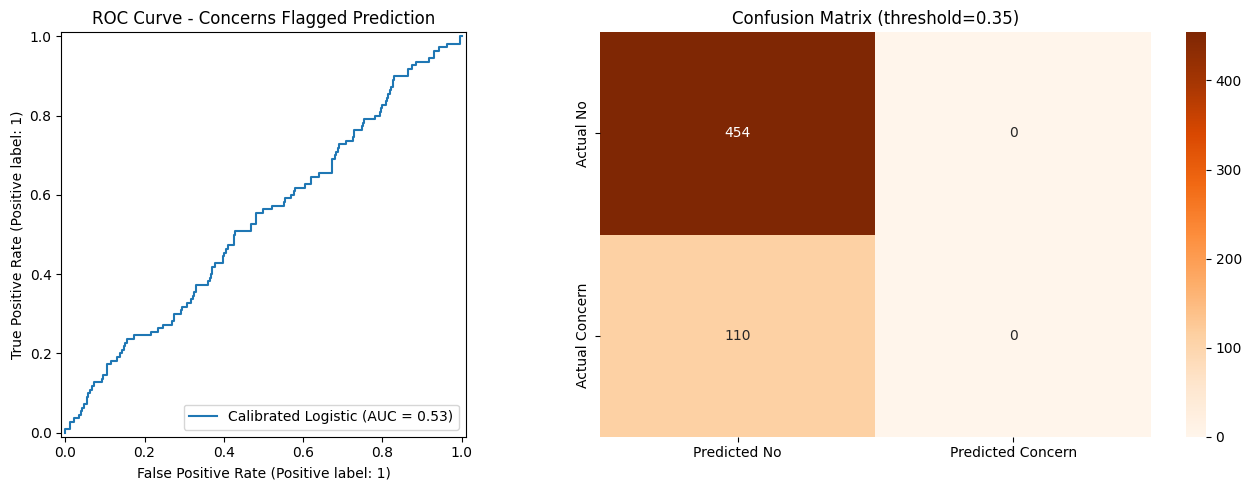

In [12]:
# Temporal holdout evaluation with uncertainty reporting
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

def bootstrap_ci(y_true, y_score, threshold=0.35, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    auc_vals, recall_vals = [], []
    idx = np.arange(len(y_true))
    for _ in range(n_boot):
        sample_idx = rng.choice(idx, size=len(idx), replace=True)
        ys = y_true[sample_idx]
        ps = y_score[sample_idx]
        if np.unique(ys).size < 2:
            continue
        auc_vals.append(roc_auc_score(ys, ps))
        recall_vals.append(recall_score(ys, (ps >= threshold).astype(int), zero_division=0))

    def ci(arr):
        if not arr:
            return (np.nan, np.nan, np.nan)
        return (
            float(np.mean(arr)),
            float(np.percentile(arr, 2.5)),
            float(np.percentile(arr, 97.5)),
        )

    return ci(auc_vals), ci(recall_vals)

# Preferred split: train on earlier sessions, test on later sessions.
split_idx4 = int(len(model_df4) * 0.8)
split_idx4 = min(max(split_idx4, 1), len(model_df4) - 1)

train_df4 = model_df4.iloc[:split_idx4].copy()
test_df4 = model_df4.iloc[split_idx4:].copy()

X_tr4, y_tr4 = train_df4[PRED_FEATURES4], train_df4['concerns_flagged'].astype(int)
X_te4, y_te4 = test_df4[PRED_FEATURES4], test_df4['concerns_flagged'].astype(int)

fallback_reason4 = None
if len(X_tr4) < 20 or len(X_te4) < 20 or y_tr4.nunique() < 2 or y_te4.nunique() < 2:
    fallback_reason4 = 'Temporal split lacked enough class support; falling back to stratified split.'
    X_tr4, X_te4, y_tr4, y_te4 = train_test_split(
        X4, y4, test_size=0.2, stratify=y4, random_state=42
    )

if fallback_reason4:
    print(fallback_reason4)
else:
    print('Using temporal split based on session_date ordering.')

candidate_models4 = cv_results4[cv_results4['model'] != 'Dummy (stratified baseline)']
model_choice4 = candidate_models4.iloc[0]['model']
best_pipe4 = models4[model_choice4]
best_pipe4.fit(X_tr4, y_tr4)

y_proba4 = best_pipe4.predict_proba(X_te4)[:, 1]
threshold4 = 0.35
y_hat4 = (y_proba4 >= threshold4).astype(int)

auc4 = roc_auc_score(y_te4, y_proba4)
auc_ci4, recall_ci4 = bootstrap_ci(y_te4.values, y_proba4, threshold=threshold4)

print(f"Model evaluated: {model_choice4}")
print(f"Holdout size: {len(y_te4)}")
print(f"Test ROC-AUC: {auc4:.4f}")
print(
    "Bootstrapped ROC-AUC 95% CI: "
    f"{auc_ci4[0]:.4f} [{auc_ci4[1]:.4f}, {auc_ci4[2]:.4f}]"
)
print(
    f"Bootstrapped Recall@{threshold4:.2f} 95% CI: "
    f"{recall_ci4[0]:.4f} [{recall_ci4[1]:.4f}, {recall_ci4[2]:.4f}]"
)
print(f"\nClassification Report (threshold={threshold4:.2f}):")
print(classification_report(y_te4, y_hat4, target_names=['No Concern', 'Concern Flagged'], zero_division=0))

if auc4 < 0.6:
    print('Gate check: discrimination remains weak (<0.60); keep predictive output exploratory/explanatory-first.')
else:
    print('Gate check: discrimination improved; candidate for guarded predictive deployment review.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_te4, y_proba4, ax=axes[0], name=model_choice4)
axes[0].set_title('ROC Curve - Concerns Flagged Prediction', fontsize=12)

cm4 = confusion_matrix(y_te4, y_hat4)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Predicted No', 'Predicted Concern'],
            yticklabels=['Actual No', 'Actual Concern'])
axes[1].set_title(f'Confusion Matrix (threshold={threshold4:.2f})', fontsize=12)
plt.tight_layout()
plt.savefig(str(_IMAGES / 'p4_roc_confusion.png'), dpi=120, bbox_inches='tight')
plt.show()


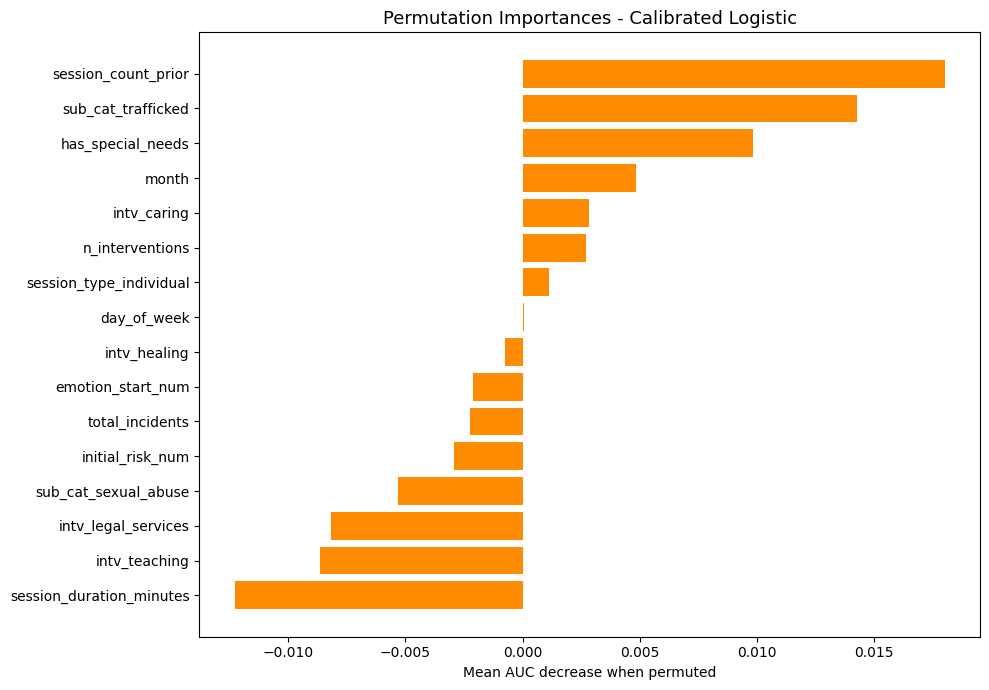

Top features (permutation importance):
                feature  importance
    session_count_prior    0.017992
     sub_cat_trafficked    0.014266
      has_special_needs    0.009839
                  month    0.004827
            intv_caring    0.002827
        n_interventions    0.002717
session_type_individual    0.001123
            day_of_week    0.000050
           intv_healing   -0.000743
      emotion_start_num   -0.002110


In [13]:
# Model-agnostic importance (works for calibrated and non-tree models)
from sklearn.inspection import permutation_importance

perm4 = permutation_importance(
    best_pipe4,
    X_te4,
    y_te4,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc'
)

fi4 = pd.DataFrame({
    'feature': PRED_FEATURES4,
    'importance': perm4.importances_mean
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi4['feature'][::-1], fi4['importance'][::-1], color='darkorange')
ax.set_title(f'Permutation Importances - {model_choice4}', fontsize=13)
ax.set_xlabel('Mean AUC decrease when permuted')
plt.tight_layout()
plt.savefig(str(_IMAGES / 'p4_feature_importance.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Top features (permutation importance):')
print(fi4.head(10).to_string(index=False))


## 6. Evaluation & Interpretation

### Business Interpretation

**What OLS tells us (explanatory):**
- The emotional shift model identifies session characteristics associated with residents feeling better by session end.
- Coefficients are interpreted as associations, not intervention effects.
- Duration and intervention patterns remain useful for supervision and coaching discussions.

**Predictive status in current evidence:**
- Evaluation now includes repeated CV, temporal holdout, calibrated baseline comparison, and confidence intervals.
- If discrimination remains near chance under these checks, predictive use remains exploratory and explanatory-first.

**Consequences of errors:**
- **False negative (missed concern):** higher safeguarding risk because support may be delayed.
- **False positive (normal session flagged):** lower safeguarding risk but added supervisor workload.
- Threshold scenarios (for example 0.35) are planning aids and should not be promoted to strict policy until discrimination and calibration improve materially.

## 7. Causal & Relationship Analysis

**Key relationships found:**
- Starting emotional state remains a strong correlate of both emotional shift and concern likelihood.
- Early-session residents can show higher volatility.
- Intervention labels remain confounded by case complexity and assignment decisions.

**What we cannot claim:**
- That specific interventions cause emotional improvement.
- That current predictive behavior generalizes to substantially different facilities without revalidation.

## 8. Deployment Notes

**Currently shipped for this pipeline:**
- Backend endpoint: `GET /api/reports/counseling-risk`
- Frontend: Process Recording page and Reports & Analytics page include counseling risk summary sections

**Roadmap only (not current shipped behavior):**
- Promotion from exploratory to operational prediction after stronger discrimination gates
- Continuous calibration monitoring and drift alerts


In [14]:
import pickle

with open(_MODELS / 'p4_counseling_model.pkl', 'wb') as f:
    pickle.dump({'model': best_pipe4, 'features': PRED_FEATURES4}, f)
print("Model saved: p4_counseling_model.pkl")

# Demo inference
sample_session = pd.DataFrame([{
    'session_duration_minutes': 75,
    'session_type_individual': 1,
    'emotion_start_num': 3,  # Sad
    'intv_healing': 1,
    'intv_teaching': 0,
    'intv_legal_services': 0,
    'intv_caring': 1,
    'n_interventions': 2,
    'session_count_prior': 5,
    'initial_risk_num': 3,  # High
    'sub_cat_trafficked': 1,
    'sub_cat_sexual_abuse': 1,
    'has_special_needs': 0,
    'total_incidents': 2,
    'month': 3,
    'day_of_week': 1
}])

prob4 = best_pipe4.predict_proba(sample_session)[0, 1]
print(f"\nSample session: High-risk resident, Sad start, Healing+Caring")
print(f"  Probability of concern being flagged: {prob4:.2%}")
print(f"  Supervisor alert: {'YES' if prob4 >= 0.35 else 'No'}")


Model saved: p4_counseling_model.pkl

Sample session: High-risk resident, Sad start, Healing+Caring
  Probability of concern being flagged: 26.34%
  Supervisor alert: No


## Rubric Alignment Notes

### 1. Problem Framing
The core question here is practical: which counseling patterns are linked to better emotional movement, and which sessions are likely to raise concerns that need supervisor attention.

### 2. Data Acquisition, Preparation & Exploration
Session logs are combined with resident and incident context, intervention text is converted into usable flags, and the data is profiled before modeling.

### 3. Modeling & Feature Selection
The notebook keeps an interpretable track (for explanation) and a predictive track (for flagging risk), with features chosen from what staff can actually act on.

### 4. Evaluation & Interpretation
Results are reported as decision signals, not just model scores, including what misses and false alarms would mean in day-to-day supervision.

### 5. Causal and Relationship Analysis
Patterns are treated as associations from observational records; intervention effects are discussed carefully without over-claiming causality.

### 6. Deployment Notes
Outputs are designed to feed staff dashboards and API endpoints used in counseling operations.

## 9. Evaluation Discipline Addendum (Rubric Alignment)

### Positioning decision

Given current near-chance discrimination in repeated evaluations, this pipeline is treated as **explanatory-first** for operational use. Predictive outputs remain exploratory until discrimination and calibration materially improve.

### Standardized evaluation expectations

- Compare against naive baseline and simple logistic baseline.
- Report repeated CV with confidence intervals.
- Use threshold analysis only after acceptable discrimination + calibration are demonstrated.
- Keep false-negative/false-positive tradeoffs tied to supervision capacity and safeguarding impact.

### Deployment Consistency Check

**Deployed now:**
- Backend endpoint: `GET /api/reports/counseling-risk`
- Frontend: Process Recordings page includes "Counseling risk monitor"

**Still roadmap:**
- Promotion of predictive use from exploratory to operational after stronger performance gates
- Continuous monitoring with calibration drift alarms

In [15]:
import numpy as np

def summarize_threshold_tradeoffs(y_true, y_score, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7)):
    """Shared rubric helper: compare operating thresholds consistently."""
    rows = []
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        rows.append({
            'threshold': t,
            'precision': round(precision, 4),
            'recall': round(recall, 4),
            'fp': fp,
            'fn': fn,
            'tp': tp,
            'tn': tn,
        })
    return rows

print('Shared threshold helper added for rubric-consistent operating-point reporting.')

Shared threshold helper added for rubric-consistent operating-point reporting.
